# Match Outcome Prediction in League of Legends

**BA-Experiment: Vergleich von Pregame vs. Ingame-State Features (Min 7 / Min 15)**

Dieses Notebook beantwortet die Forschungsfragen der Bachelorarbeit:

- **RQ1**: Wie unterscheidet sich die Vorhersageleistung zwischen Min 7 und Min 15?
- **RQ2**: Welche Features tragen am meisten zur Vorhersage bei?
- **RQ3**: Ab wann reicht die Information für eine zuverlässige Vorhersage?

## Versuchsaufbau

| Condition | Features | Simuliert |
|---|---|---|
| **A - Pregame** | Champion-Picks (kodiert als Winrates) | Draft-Zeit |
| **B - Pregame + Min 7** | A + Gold/Kill/Tower/Dragon-Diff @ Min 7 | Frühe Phase |
| **C - Pregame + Min 15** | A + Gold/Kill/Tower/Dragon-Diff @ Min 15 | Mittlere Phase |

Jede Condition wird mit **3 Modellen** trainiert: Random Forest, XGBoost, Neural Network -> **9 Experimente** insgesamt.

## Wichtige methodische Entscheidungen

1. **Champion-Encoding**: Champion-IDs werden als positionsspezifische Winrates kodiert (statt als rohe IDs oder One-Hot). Das vermeidet das Problem, dass Modelle hohe IDs als \"besser\" interpretieren.
2. **Train/Val/Test Split**: 70 % / 15 % / 15 %, stratifiziert nach Target. Derselbe Split wird für alle 9 Experimente verwendet - dadurch sind die Ergebnisse fair vergleichbar.
3. **Kein Data Leakage**: Winrates werden ausschließlich aus dem Training-Set berechnet und dann auf alle Sets angewendet.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data" / "datasets").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / "data" / "datasets" / "v2_match_dataset_5000.csv"
CHARTS_DIR = PROJECT_ROOT / "v2" / "notebooks" / "charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

POSITIONS = ["top", "jungle", "mid", "adc", "support"]
CHAMP_COLS = [f"team{t}_{p}" for t in (1, 2) for p in POSITIONS]
M7_COLS = ["gold_diff_m7", "kill_diff_m7", "tower_diff_m7", "dragon_diff_m7"]
M15_COLS = ["gold_diff_m15", "kill_diff_m15", "tower_diff_m15", "dragon_diff_m15"]

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_PATH: {DATA_PATH}")
print(f"DATA_PATH exists: {DATA_PATH.exists()}")
print(f"CHARTS_DIR: {CHARTS_DIR}")

PROJECT_ROOT: c:\winrate-prediction-lol
DATA_PATH: c:\winrate-prediction-lol\data\datasets\v2_match_dataset_5000.csv
DATA_PATH exists: True
CHARTS_DIR: c:\winrate-prediction-lol\v2\notebooks\charts


## 1. Daten laden

Wir laden den V2-Datensatz mit 7,500 High-Elo Ranked Solo/Duo Matches (Challenger / GM / Master) aus 14 Regionen.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Matches: {len(df)}")
print(f"Spalten: {len(df.columns)}")
print(f"Regionen: {df['region'].nunique()}  -> {sorted(df['region'].unique())}")
print(f"Target-Verteilung: {df['target'].value_counts().to_dict()}")
print(f"Win-Quote (target=1): {(df['target'] == 1).mean():.4f}")
df.head()

Matches: 7500
Spalten: 21
Regionen: 14  -> ['br1', 'eun1', 'euw1', 'jp1', 'kr', 'la1', 'la2', 'na1', 'oc1', 'ru', 'sg2', 'tr1', 'tw2', 'vn2']
Target-Verteilung: {0: 4094, 1: 3406}
Win-Quote (target=1): 0.4541


,match_id,target,team1_top,team1_jungle,team1_mid,team1_adc,team1_support,team2_top,team2_jungle,team2_mid,...,team2_support,gold_diff_m7,kill_diff_m7,tower_diff_m7,dragon_diff_m7,gold_diff_m15,kill_diff_m15,tower_diff_m15,dragon_diff_m15,region
0,EUW1_7828623639,1,68,5,238,910,267,799,131,893,...,555,-1266,0,0,0,1884,4,1,-2,euw1
1,EUW1_7828182032,1,150,266,134,800,99,92,56,103,...,267,1285,1,0,0,3966,1,2,2,euw1
2,EUW1_7828137723,1,39,163,58,81,111,68,62,92,...,43,-1423,-5,0,0,-2284,-6,-1,-1,euw1
3,EUW1_7828110604,1,83,254,3,51,518,126,950,112,...,117,984,3,0,0,850,3,2,0,euw1
4,EUW1_7828066348,0,14,163,777,29,555,67,266,34,...,412,-1931,-5,0,-1,-5071,-11,-1,-2,euw1


## 2. Train / Validation / Test Split

**Wichtig:** Wir splitten EINMAL und verwenden denselben Split für alle 9 Experimente.
Nur so sind die Modelle fair vergleichbar.

- **70 % Training** (~5,250 Matches): Modelle werden hierauf gefittet.
- **15 % Validation** (~1,125 Matches): Reserviert für Hyperparameter-Tuning / Early Stopping.
- **15 % Test** (~1,125 Matches): Wird ausschließlich für das finale Reporting verwendet.

Stratifiziert nach `target`, damit alle Splits dieselbe Win-Quote haben.

In [3]:
y = df["target"].astype(int)

indices = np.arange(len(df))
trainval_idx, test_idx = train_test_split(
    indices, test_size=0.15, random_state=RANDOM_STATE, stratify=y,
)
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=0.15 / 0.85,
    random_state=RANDOM_STATE,
    stratify=y.iloc[trainval_idx],
)

print(f"Train: {len(train_idx):>4}  ({len(train_idx)/len(df):.1%})")
print(f"Val:   {len(val_idx):>4}  ({len(val_idx)/len(df):.1%})")
print(f"Test:  {len(test_idx):>4}  ({len(test_idx)/len(df):.1%})")
print()
print("Win-Quote pro Split:")
print(f"  Train: {y.iloc[train_idx].mean():.4f}")
print(f"  Val:   {y.iloc[val_idx].mean():.4f}")
print(f"  Test:  {y.iloc[test_idx].mean():.4f}")

Train: 5250  (70.0%)
Val:   1125  (15.0%)
Test:  1125  (15.0%)

Win-Quote pro Split:
  Train: 0.4541
  Val:   0.4542
  Test:  0.4542


## 3. Champion-Encoding via positionsspezifische Winrates

**Problem (vom letzten Mal):** Wenn man Champion-IDs einfach als Zahl an das Modell gibt, lernt es z. B. "Champion 950 ist besser als Champion 1" - das ist Unsinn, denn die IDs sind nur Bezeichner.

**Lösung (wie im alten Projekt):** Wir wandeln jede Champion-ID in eine **positionsspezifische Winrate** um, berechnet **ausschließlich aus dem Training-Set**.

Beispiel: Wenn Aatrox als Top-Laner in 200 Trainings-Matches in 110 davon gewonnen hat, bekommt jede neue Aatrox-Top-Reihe eine `team1_top_winrate = 0.55` (bzw. mit Laplace-Smoothing leicht in Richtung 0.5 gezogen, damit seltene Champions stabil sind).

Daraus leiten wir noch zwei Aggregat-Features ab:
- `team1_avg_winrate` und `team2_avg_winrate`
- `winrate_diff` = team1_avg_winrate - team2_avg_winrate

Insgesamt: **13 Pregame-Features** (10 Rollen + 2 Team-Mittelwerte + 1 Diff).

In [4]:
def compute_champion_winrates(df_train: pd.DataFrame, alpha: float = 10.0) -> dict:
    """Positionsspezifische Champion-Winrates aus Training-Daten.

    Laplace-Smoothing (Beta(alpha, alpha) Prior) zieht seltene Champions Richtung 0.5
    und verhindert Overfitting auf wenige Beobachtungen.
    """
    winrates: dict = {}
    target = df_train["target"].astype(int).values

    for pos in POSITIONS:
        wins = {}
        total = {}
        for team in (1, 2):
            champs = df_train[f"team{team}_{pos}"].astype(int).values
            for champ_id, t in zip(champs, target):
                key = int(champ_id)
                total[key] = total.get(key, 0) + 1
                won = (team == 1 and t == 1) or (team == 2 and t == 0)
                wins[key] = wins.get(key, 0) + int(won)
        for champ_id, total_count in total.items():
            won_count = wins.get(champ_id, 0)
            winrates[(pos, champ_id)] = (won_count + alpha) / (total_count + 2.0 * alpha)

    return winrates


def add_winrate_features(df: pd.DataFrame, winrates: dict) -> pd.DataFrame:
    """Fügt Winrate-Features hinzu (lässt Originalspalten unverändert)."""
    out = df.copy()
    for pos in POSITIONS:
        for team in (1, 2):
            col = f"team{team}_{pos}"
            out[f"team{team}_{pos}_winrate"] = out[col].astype(int).map(
                lambda c, p=pos: winrates.get((p, int(c)), 0.5)
            )
    for team in (1, 2):
        cols = [f"team{team}_{p}_winrate" for p in POSITIONS]
        out[f"team{team}_avg_winrate"] = out[cols].mean(axis=1)
    out["winrate_diff"] = out["team1_avg_winrate"] - out["team2_avg_winrate"]
    return out


df_train_only = df.iloc[train_idx]
winrates = compute_champion_winrates(df_train_only)
print(f"Berechnete Winrates: {len(winrates)} (pos, champion_id)-Paare aus dem Training-Set")

df_features = add_winrate_features(df, winrates)
WINRATE_COLS = (
    [f"team{t}_{p}_winrate" for t in (1, 2) for p in POSITIONS]
    + ["team1_avg_winrate", "team2_avg_winrate", "winrate_diff"]
)
print(f"Neue Pregame-Features: {len(WINRATE_COLS)}")
df_features[WINRATE_COLS].head()

Berechnete Winrates: 617 (pos, champion_id)-Paare aus dem Training-Set
Neue Pregame-Features: 13


,team1_top_winrate,team1_jungle_winrate,team1_mid_winrate,team1_adc_winrate,team1_support_winrate,team2_top_winrate,team2_jungle_winrate,team2_mid_winrate,team2_adc_winrate,team2_support_winrate,team1_avg_winrate,team2_avg_winrate,winrate_diff
0,0.503425,0.521368,0.505376,0.567568,0.472316,0.460199,0.494565,0.520000,0.505172,0.510363,0.514010,0.498060,0.015951
1,0.451613,0.542714,0.475570,0.527778,0.521429,0.496528,0.528481,0.493171,0.542517,0.472316,0.503821,0.506603,-0.002782
2,0.521429,0.509677,0.533333,0.485669,0.499246,0.503425,0.450000,0.396552,0.500803,0.502800,0.509871,0.470716,0.039155
3,0.492537,0.476703,0.470175,0.500803,0.449580,0.461947,0.528150,0.513064,0.490741,0.476994,0.477960,0.494179,-0.016220
4,0.453674,0.509677,0.452962,0.495050,0.510363,0.546667,0.542714,0.549342,0.563923,0.512146,0.484345,0.542958,-0.058613


## 4. Feature-Sets für die 3 Conditions

Statt 3 verschiedener CSV-Dateien definieren wir einfach 3 Spaltenauswahlen aus demselben DataFrame.

In [5]:
FEATURE_SETS = {
    "Pregame":          WINRATE_COLS,
    "Pregame + Min 7":  WINRATE_COLS + M7_COLS,
    "Pregame + Min 15": WINRATE_COLS + M15_COLS,
}

for name, cols in FEATURE_SETS.items():
    print(f"{name:20} -> {len(cols)} Features")

Pregame              -> 13 Features
Pregame + Min 7      -> 17 Features
Pregame + Min 15     -> 17 Features


## 5. Modelle definieren

Drei Modellfamilien wie in der BA-Anmeldung beschrieben:

- **Random Forest**: Ensemble aus Entscheidungsbäumen, robust gegen Skalen.
- **XGBoost**: Gradient-Boosted Trees, oft Top-Performer auf Tabellendaten.
- **Neural Network (MLP)**: Mehrschichtiges Perzeptron, profitiert von skalierten Inputs.

Hyperparameter sind konservativ gewählt (regularisiert) - bei nur 7,500 Matches verhindert das Overfitting.

In [6]:
def make_models() -> dict:
    """Frische Modell-Instanzen pro Experiment."""
    return {
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=15,
            min_samples_leaf=8,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1,
        ),
        "Neural Network": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=1e-3,
            max_iter=200,
            early_stopping=True,
            n_iter_no_change=15,
            random_state=RANDOM_STATE,
        ),
    }


MODEL_NAMES = list(make_models().keys())
print("Modelle:", MODEL_NAMES)

Modelle: ['Random Forest', 'XGBoost', 'Neural Network']


## 6. Experiment-Loop: 3 Conditions x 3 Modelle = 9 Trainings

Pro Kombination:
1. Features-Subset auswählen
2. Skalieren (nur für das NN nötig, für Konsistenz aber bei allen)
3. Modell auf Train fitten
4. Auf Test evaluieren -> Accuracy + ROC-AUC speichern

In [7]:
results = []
trained: dict = {}

for cond_name, feature_cols in FEATURE_SETS.items():
    X_train = df_features.iloc[train_idx][feature_cols].values
    X_val   = df_features.iloc[val_idx][feature_cols].values
    X_test  = df_features.iloc[test_idx][feature_cols].values
    y_train = y.iloc[train_idx].values
    y_val   = y.iloc[val_idx].values
    y_test  = y.iloc[test_idx].values

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)

    for model_name, model in make_models().items():
        if model_name == "Neural Network":
            model.fit(X_train_s, y_train)
            y_pred  = model.predict(X_test_s)
            y_proba = model.predict_proba(X_test_s)[:, 1]
        else:
            model.fit(X_train, y_train)
            y_pred  = model.predict(X_test)
            y_proba = model.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)

        results.append({
            "Condition": cond_name,
            "Model":     model_name,
            "Accuracy":  acc,
            "ROC-AUC":   auc,
        })
        trained[(cond_name, model_name)] = {
            "model":   model,
            "y_pred":  y_pred,
            "y_proba": y_proba,
            "y_test":  y_test,
            "features": feature_cols,
        }

        print(f"{cond_name:20} | {model_name:15} | Acc: {acc:.4f} | AUC: {auc:.4f}")

results_df = pd.DataFrame(results)

Pregame              | Random Forest   | Acc: 0.5404 | AUC: 0.5440


Pregame              | XGBoost         | Acc: 0.5387 | AUC: 0.5370


Pregame              | Neural Network  | Acc: 0.5324 | AUC: 0.5398


Pregame + Min 7      | Random Forest   | Acc: 0.6453 | AUC: 0.7011


Pregame + Min 7      | XGBoost         | Acc: 0.6338 | AUC: 0.6859


Pregame + Min 7      | Neural Network  | Acc: 0.6338 | AUC: 0.6979


Pregame + Min 15     | Random Forest   | Acc: 0.7502 | AUC: 0.8341


Pregame + Min 15     | XGBoost         | Acc: 0.7351 | AUC: 0.8218


Pregame + Min 15     | Neural Network  | Acc: 0.7529 | AUC: 0.8293


## 7. Ergebnistabelle

In [8]:
pivot_acc = results_df.pivot(index="Model", columns="Condition", values="Accuracy")
pivot_auc = results_df.pivot(index="Model", columns="Condition", values="ROC-AUC")
col_order = ["Pregame", "Pregame + Min 7", "Pregame + Min 15"]
pivot_acc = pivot_acc[col_order]
pivot_auc = pivot_auc[col_order]

print("=== Accuracy ===")
print(pivot_acc.round(4).to_string())
print()
print("=== ROC-AUC ===")
print(pivot_auc.round(4).to_string())

=== Accuracy ===
Condition       Pregame  Pregame + Min 7  Pregame + Min 15
Model                                                     
Neural Network   0.5324           0.6338            0.7529
Random Forest    0.5404           0.6453            0.7502
XGBoost          0.5387           0.6338            0.7351

=== ROC-AUC ===
Condition       Pregame  Pregame + Min 7  Pregame + Min 15
Model                                                     
Neural Network   0.5398           0.6979            0.8293
Random Forest    0.5440           0.7011            0.8341
XGBoost          0.5370           0.6859            0.8218


## 8. Visualization

### 8.1 Accuracy & ROC-AUC by Model and Condition

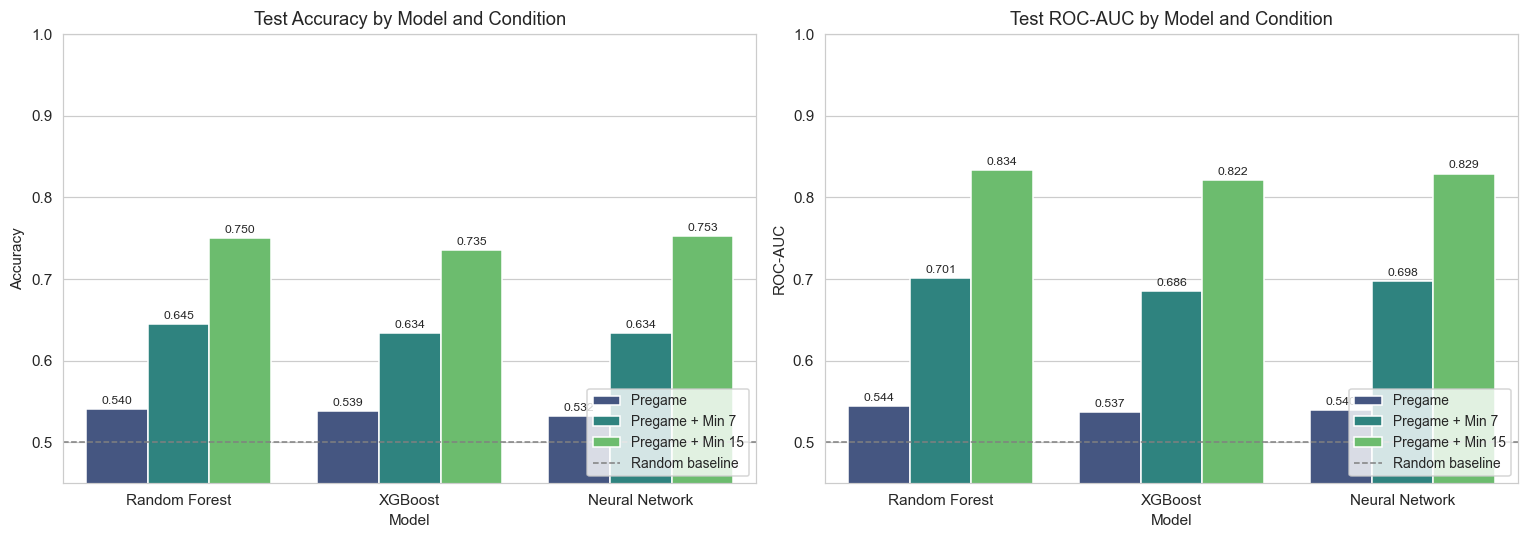

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in [
    (axes[0], "Accuracy", "Test Accuracy by Model and Condition"),
    (axes[1], "ROC-AUC",  "Test ROC-AUC by Model and Condition"),
]:
    sns.barplot(data=results_df, x="Model", y=metric, hue="Condition",
                hue_order=col_order, ax=ax, palette="viridis")
    ax.set_title(title)
    ax.set_ylim(0.45, 1.0)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="Random baseline")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=2, fontsize=8)
    ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(CHARTS_DIR / "01_accuracy_aucroc_bars.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.2 ROC Curves by Condition

Compares the three models within each condition. The closer the curve to the top-left corner, the better.

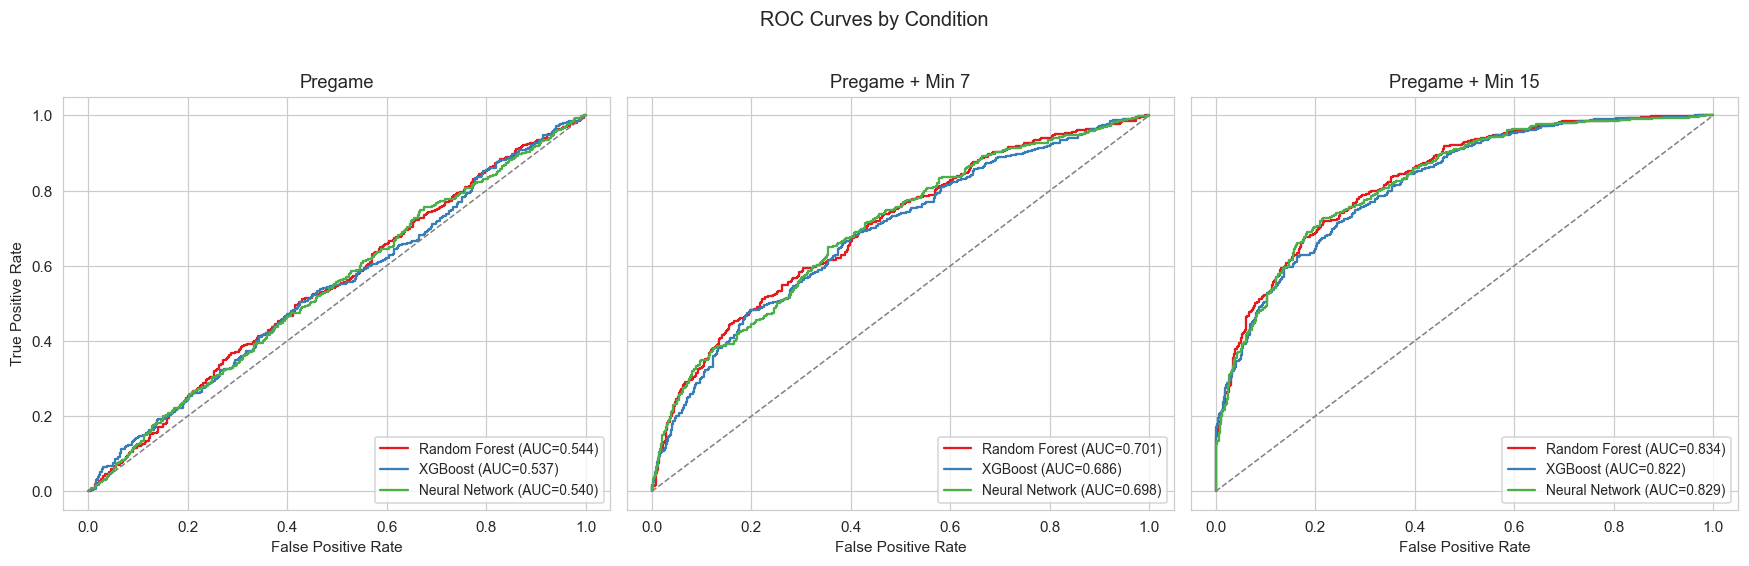

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
colors = sns.color_palette("Set1", n_colors=len(MODEL_NAMES))

for ax, cond_name in zip(axes, col_order):
    for color, model_name in zip(colors, MODEL_NAMES):
        run = trained[(cond_name, model_name)]
        fpr, tpr, _ = roc_curve(run["y_test"], run["y_proba"])
        auc = roc_auc_score(run["y_test"], run["y_proba"])
        ax.plot(fpr, tpr, color=color, label=f"{model_name} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--", linewidth=1)
    ax.set_title(cond_name)
    ax.set_xlabel("False Positive Rate")
    ax.legend(loc="lower right", fontsize=9)
axes[0].set_ylabel("True Positive Rate")

plt.suptitle("ROC Curves by Condition", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(CHARTS_DIR / "02_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.3 Confusion Matrices

Shows how each of the 9 models splits its errors (False Positives / False Negatives).

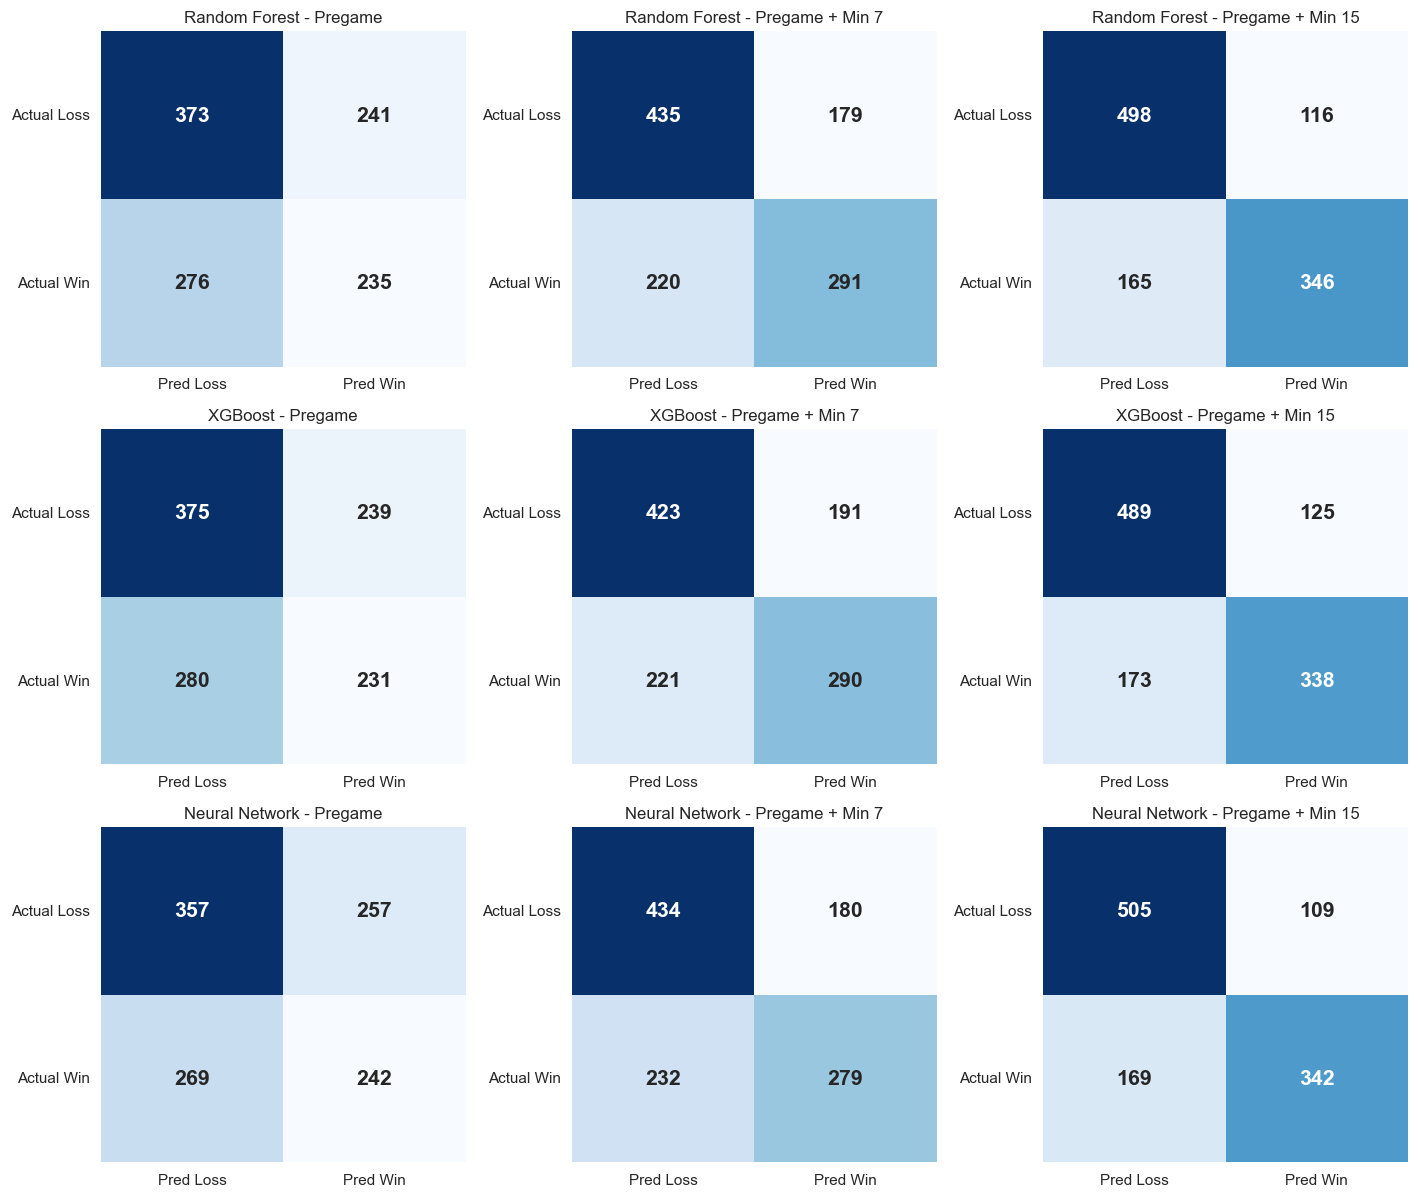

In [11]:
fig, axes = plt.subplots(len(MODEL_NAMES), len(col_order), figsize=(13, 11))

for i, model_name in enumerate(MODEL_NAMES):
    for j, cond_name in enumerate(col_order):
        run = trained[(cond_name, model_name)]
        cm = confusion_matrix(run["y_test"], run["y_pred"])
        ax = axes[i, j]
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred Loss", "Pred Win"],
            yticklabels=["Actual Loss", "Actual Win"],
            annot_kws={"size": 14, "weight": "bold"},
            ax=ax,
        )
        ax.set_title(f"{model_name} - {cond_name}", fontsize=11)
        ax.tick_params(axis="x", labelsize=10)
        ax.tick_params(axis="y", labelsize=10, rotation=0)

plt.tight_layout()
plt.savefig(CHARTS_DIR / "03_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.4 Feature Importance (Random Forest)

Shows which features each Random Forest model relies on most strongly per condition - important for **RQ2**.

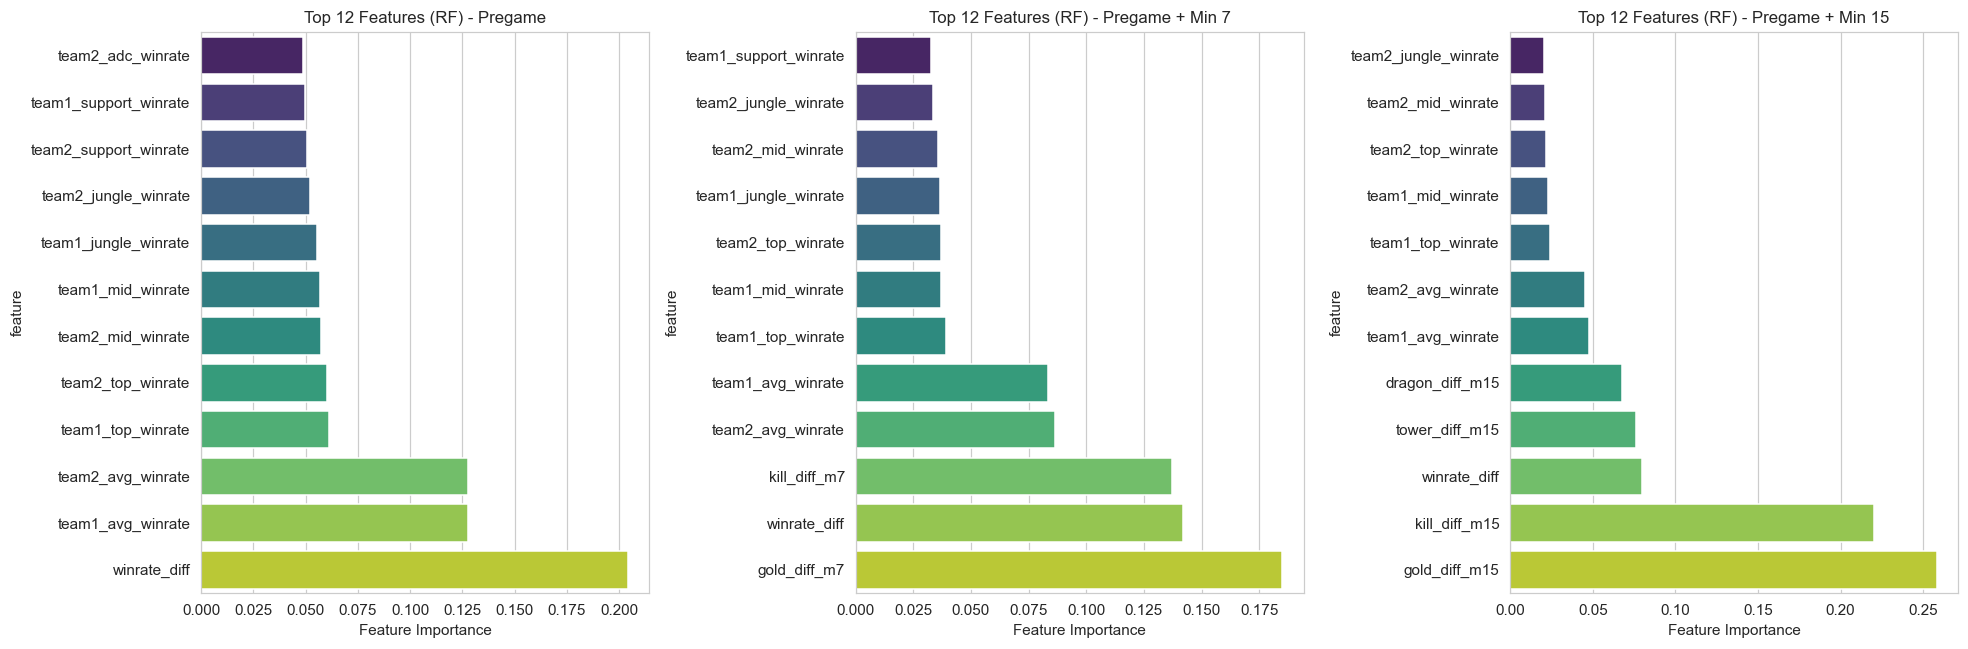

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, cond_name in zip(axes, col_order):
    run = trained[(cond_name, "Random Forest")]
    importances = run["model"].feature_importances_
    feat_names = run["features"]

    imp = (
        pd.DataFrame({"feature": feat_names, "importance": importances})
        .sort_values("importance", ascending=True)
        .tail(12)
    )
    sns.barplot(data=imp, x="importance", y="feature", ax=ax, palette="viridis")
    ax.set_title(f"Top 12 Features (RF) - {cond_name}", fontsize=11)
    ax.set_xlabel("Feature Importance")

plt.tight_layout()
plt.savefig(CHARTS_DIR / "04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Interpretation & Bezug zu den Forschungsfragen

Die Zellen unten leiten die Antworten auf RQ1 / RQ2 / RQ3 direkt aus `results_df` ab. Du kannst die ausgegebenen Sätze mit minimaler Anpassung in den Ergebnis-Teil deiner BA übernehmen.

In [13]:
print("=" * 70)
print("RQ1 - Wie verbessert sich die Prediction von Min 7 zu Min 15?")
print("=" * 70)
for model_name in MODEL_NAMES:
    pre = pivot_acc.loc[model_name, "Pregame"]
    m7  = pivot_acc.loc[model_name, "Pregame + Min 7"]
    m15 = pivot_acc.loc[model_name, "Pregame + Min 15"]
    print(
        f"  {model_name:15} | Pregame={pre:.3f}  Min7={m7:.3f} ({m7-pre:+.3f})  "
        f"Min15={m15:.3f} ({m15-pre:+.3f})"
    )

print()
print("=" * 70)
print("RQ2 - Wichtigste Timeline-Features (Random Forest, Pregame + Min 15)")
print("=" * 70)
rf_m15 = trained[("Pregame + Min 15", "Random Forest")]
imp_df = (
    pd.DataFrame({"feature": rf_m15["features"], "importance": rf_m15["model"].feature_importances_})
    .sort_values("importance", ascending=False)
    .head(8)
)
print(imp_df.to_string(index=False))

print()
print("=" * 70)
print("RQ3 - Information Threshold")
print("=" * 70)
best = results_df.loc[results_df["ROC-AUC"].idxmax()]
print(f"  Bestes Modell überhaupt: {best['Model']} mit '{best['Condition']}' "
      f"-> Acc {best['Accuracy']:.3f}, AUC {best['ROC-AUC']:.3f}")
gain = pivot_acc["Pregame + Min 15"].mean() - pivot_acc["Pregame"].mean()
print(f"  Durchschn. Acc-Gewinn von Pregame -> Min15: {gain:+.3f}")

RQ1 - Wie verbessert sich die Prediction von Min 7 zu Min 15?
  Random Forest   | Pregame=0.540  Min7=0.645 (+0.105)  Min15=0.750 (+0.210)
  XGBoost         | Pregame=0.539  Min7=0.634 (+0.095)  Min15=0.735 (+0.196)
  Neural Network  | Pregame=0.532  Min7=0.634 (+0.101)  Min15=0.753 (+0.220)

RQ2 - Wichtigste Timeline-Features (Random Forest, Pregame + Min 15)
          feature  importance
    gold_diff_m15    0.258185
    kill_diff_m15    0.220342
     winrate_diff    0.079848
   tower_diff_m15    0.076252
  dragon_diff_m15    0.067807
team1_avg_winrate    0.047503
team2_avg_winrate    0.045229
team1_top_winrate    0.023911

RQ3 - Information Threshold
  Bestes Modell überhaupt: Random Forest mit 'Pregame + Min 15' -> Acc 0.750, AUC 0.834
  Durchschn. Acc-Gewinn von Pregame -> Min15: +0.209
